In [15]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

import numpy as np
from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, \
    TimeSeriesResampler
import seaborn as sns
from tslearn.utils import to_time_series_dataset
from tslearn.clustering import silhouette_score

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import sklearn.cluster

import os
from yellowbrick.cluster import SilhouetteVisualizer

import math
import scipy

from sklearn.metrics import adjusted_rand_score

## Visualization Function

In [16]:
def ts_cluster_visualization(y_pred, df, n_clusters, plot_title):
    ts_size = df.shape[1]
    ts_max = df.max()
    plt.figure()
    for cluster in range(n_clusters):
        plt.subplot(4, math.ceil(n_clusters/4), cluster+1)
        for ts in df[y_pred == cluster]:
            plt.plot(ts.ravel(), "k-", alpha=.2)
        plt.plot(np.mean(df[y_pred == cluster], axis=0), "r-")
        plt.xlim(0, ts_size)
        plt.ylim(0, ts_max)
        plt.text(0.55, 0.35,'Cluster %d' % (cluster),
                 transform=plt.gca().transAxes)
        if cluster == 1:
            plt.title(plot_title)      
    plt.tight_layout()
    plt.show()

## Distance Function

In [17]:
def ts_cluster_distance(y_pred, df, n_clusters, distance_measure):
    distances = list()
    for cluster in range(n_clusters):
        cluster_center = np.mean(df[y_pred == cluster], axis=0)
        for ts in df[y_pred == cluster]:
            if(distance_measure == "Euclidean"):
                diff = np.sqrt(np.sum((ts.ravel() - cluster_center)**2))
                distances.append(diff)
    return np.mean(distances)

## Bank Reserves

In [18]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
br_poor = pd.read_csv("SimData/bank_reserves_outputs_poor.csv", header=None)
br_poor_ts = to_time_series_dataset(br_poor)

In [19]:
distance_br_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), br_poor_ts, 7, "Euclidean")

distance_br_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), br_poor_ts, 7, "Euclidean")

distance_br_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), br_poor_ts, 7, "Euclidean")

In [20]:
br_results_poor_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_br_pca_kmeans, distance_br_pca_agglom, distance_br_pca_spectral, 
              distance_br_dae_kmeans, distance_br_dae_agglom, distance_br_dae_spectral,
              distance_br_dcae_kmeans, distance_br_dcae_agglom, distance_br_dcae_spectral]
})

In [21]:
br_poor = pd.read_csv("SimData/bank_reserves_outputs_middle.csv", header=None)
br_poor_ts = to_time_series_dataset(br_poor)

In [22]:
distance_br_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), br_poor_ts, 7, "Euclidean")

distance_br_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), br_poor_ts, 7, "Euclidean")

distance_br_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), br_poor_ts, 7, "Euclidean")

In [23]:
br_results_middle_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_br_pca_kmeans, distance_br_pca_agglom, distance_br_pca_spectral, 
              distance_br_dae_kmeans, distance_br_dae_agglom, distance_br_dae_spectral,
              distance_br_dcae_kmeans, distance_br_dcae_agglom, distance_br_dcae_spectral]
})

In [24]:
br_results_middle_df

,Feature,Cluster,Value
0,PCA,KMeans,7807.927980
1,PCA,Agglomerative,7746.804364
2,PCA,Spectral,7597.069312
3,DAE,KMeans,7588.486963
4,DAE,Agglomerative,7586.074503
5,DAE,Spectral,7594.094847
6,DCAE,KMeans,7590.114340
7,DCAE,Agglomerative,7686.050941
8,DCAE,Spectral,7591.325372


In [25]:
br_poor = pd.read_csv("SimData/bank_reserves_outputs_rich.csv", header=None)
br_poor_ts = to_time_series_dataset(br_poor)

In [26]:
distance_br_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), br_poor_ts, 7, "Euclidean")

distance_br_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), br_poor_ts, 7, "Euclidean")

distance_br_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), br_poor_ts, 7, "Euclidean")
distance_br_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), br_poor_ts, 7, "Euclidean")

In [27]:
br_results_rich_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_br_pca_kmeans, distance_br_pca_agglom, distance_br_pca_spectral, 
              distance_br_dae_kmeans, distance_br_dae_agglom, distance_br_dae_spectral,
              distance_br_dcae_kmeans, distance_br_dcae_agglom, distance_br_dcae_spectral]
})

In [28]:
br_results_rich_df

,Feature,Cluster,Value
0,PCA,KMeans,4190.254775
1,PCA,Agglomerative,4177.940803
2,PCA,Spectral,4147.436889
3,DAE,KMeans,4152.373717
4,DAE,Agglomerative,4152.123627
5,DAE,Spectral,4153.372245
6,DCAE,KMeans,4153.802795
7,DCAE,Agglomerative,4170.820159
8,DCAE,Spectral,4154.467995


In [31]:
br_results_poor_df['Value'] = br_results_poor_df['Value'].apply(lambda x: x/3977.98219752392)
br_results_middle_df['Value'] = br_results_middle_df['Value'].apply(lambda x: x/7545.545921881597)
br_results_rich_df['Value'] = br_results_rich_df['Value'].apply(lambda x: x/4144.924998186655)

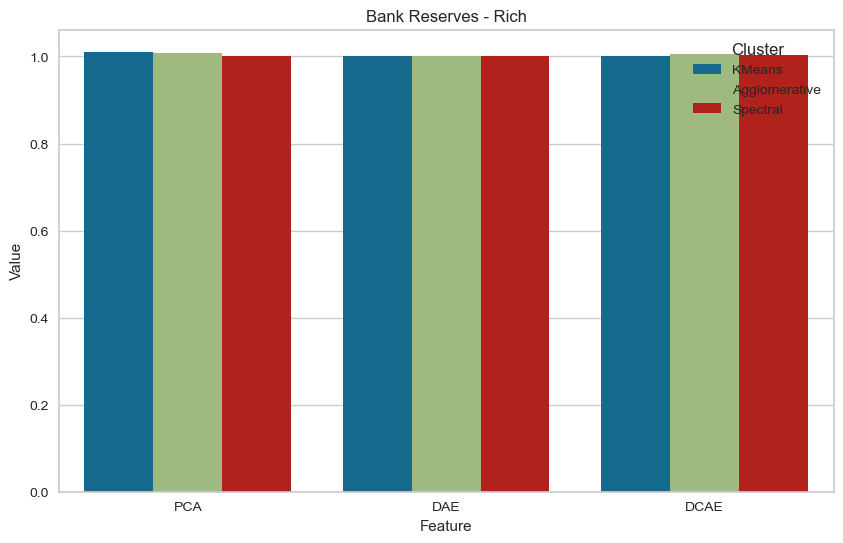

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(data=br_results_rich_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Bank Reserves - Rich")
plt.legend(title="Cluster")
#plt.ylim(3800, 4300)
plt.savefig("bank_reserves_rich_overall_norm.png", format="png")
plt.show()

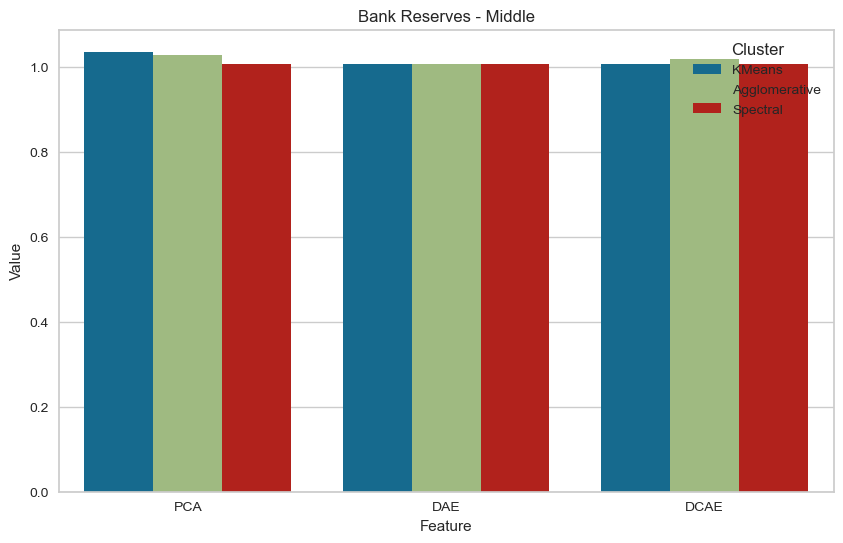

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(data=br_results_middle_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Bank Reserves - Middle")
plt.legend(title="Cluster")
#plt.ylim(7200, 7900)
plt.savefig("bank_reserves_middle_overall_norm.png", format="png")
plt.show()

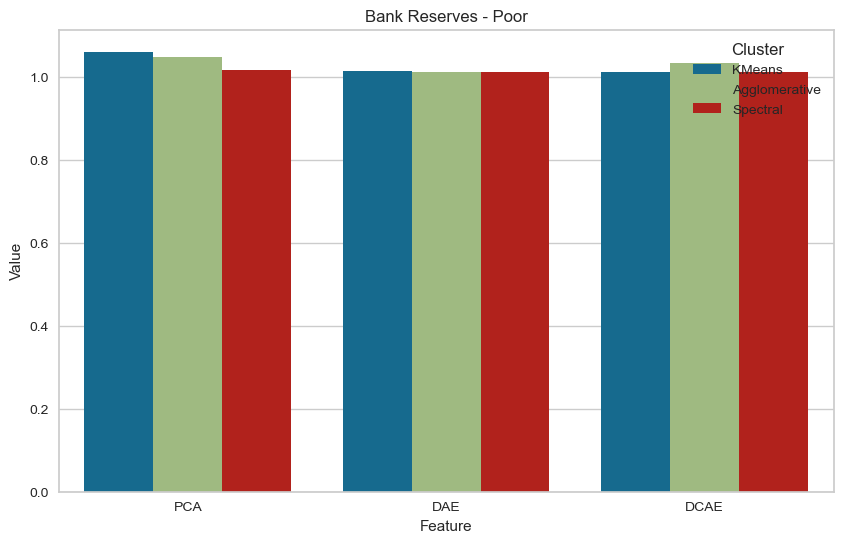

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(data=br_results_poor_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Bank Reserves - Poor")
plt.legend(title="Cluster")
#plt.ylim(3800, 4300)
plt.savefig("bank_reserves_poor_overall_norm.png", format="png")
plt.show()

# Epstein

In [37]:
label_results = pd.read_csv('epstein_results.csv', index_col=0)
ecv_active = pd.read_csv("SimData/epsteinCV_outputs_active.csv", header=None)
ecv_active_ts = to_time_series_dataset(ecv_active)

In [38]:
distance_ecv_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ecv_active_ts, 8, "Euclidean")
distance_ecv_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ecv_active_ts, 8, "Euclidean")
distance_ecv_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ecv_active_ts, 8, "Euclidean")

distance_ecv_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ecv_active_ts, 8, "Euclidean")
distance_ecv_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ecv_active_ts, 8, "Euclidean")
distance_ecv_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ecv_active_ts, 8, "Euclidean")

distance_ecv_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ecv_active_ts, 8, "Euclidean")
distance_ecv_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ecv_active_ts, 8, "Euclidean")
distance_ecv_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ecv_active_ts, 8, "Euclidean")

In [39]:
ecv_results_active_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ecv_pca_kmeans, distance_ecv_pca_agglom, distance_ecv_pca_spectral, 
              distance_ecv_dae_kmeans, distance_ecv_dae_agglom, distance_ecv_dae_spectral,
              distance_ecv_dcae_kmeans, distance_ecv_dcae_agglom, distance_ecv_dcae_spectral]
})

In [40]:
ecv_jailed = pd.read_csv("SimData/epsteinCV_outputs_jailed.csv", header=None)
ecv_jailed_ts = to_time_series_dataset(ecv_jailed)

In [41]:
distance_ecv_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ecv_jailed_ts, 8, "Euclidean")
distance_ecv_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ecv_jailed_ts, 8, "Euclidean")
distance_ecv_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ecv_jailed_ts, 8, "Euclidean")

distance_ecv_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ecv_jailed_ts, 8, "Euclidean")
distance_ecv_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ecv_jailed_ts, 8, "Euclidean")
distance_ecv_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ecv_jailed_ts, 8, "Euclidean")

distance_ecv_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ecv_jailed_ts, 8, "Euclidean")
distance_ecv_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ecv_jailed_ts, 8, "Euclidean")
distance_ecv_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ecv_jailed_ts, 8, "Euclidean")

In [42]:
ecv_results_jailed_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ecv_pca_kmeans, distance_ecv_pca_agglom, distance_ecv_pca_spectral, 
              distance_ecv_dae_kmeans, distance_ecv_dae_agglom, distance_ecv_dae_spectral,
              distance_ecv_dcae_kmeans, distance_ecv_dcae_agglom, distance_ecv_dcae_spectral]
})

In [43]:
ecv_quiet = pd.read_csv("SimData/epsteinCV_outputs_quiet.csv", header=None)
ecv_quiet_ts = to_time_series_dataset(ecv_quiet)

In [44]:
distance_ecv_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ecv_quiet_ts, 8, "Euclidean")
distance_ecv_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ecv_quiet_ts, 8, "Euclidean")
distance_ecv_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ecv_quiet_ts, 8, "Euclidean")

distance_ecv_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ecv_quiet_ts, 8, "Euclidean")
distance_ecv_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ecv_quiet_ts, 8, "Euclidean")
distance_ecv_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ecv_quiet_ts, 8, "Euclidean")

distance_ecv_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ecv_quiet_ts, 8, "Euclidean")
distance_ecv_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ecv_quiet_ts, 8, "Euclidean")
distance_ecv_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ecv_quiet_ts, 8, "Euclidean")

In [45]:
ecv_results_quiet_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ecv_pca_kmeans, distance_ecv_pca_agglom, distance_ecv_pca_spectral, 
              distance_ecv_dae_kmeans, distance_ecv_dae_agglom, distance_ecv_dae_spectral,
              distance_ecv_dcae_kmeans, distance_ecv_dcae_agglom, distance_ecv_dcae_spectral]
})

In [46]:
ecv_results_active_df['Value'] = ecv_results_active_df['Value'].apply(lambda x: x/15374.578709870502)
ecv_results_jailed_df['Value'] = ecv_results_jailed_df['Value'].apply(lambda x: x/16884.45670490543)
ecv_results_quiet_df['Value'] = ecv_results_quiet_df['Value'].apply(lambda x: x/27407.50932757308)

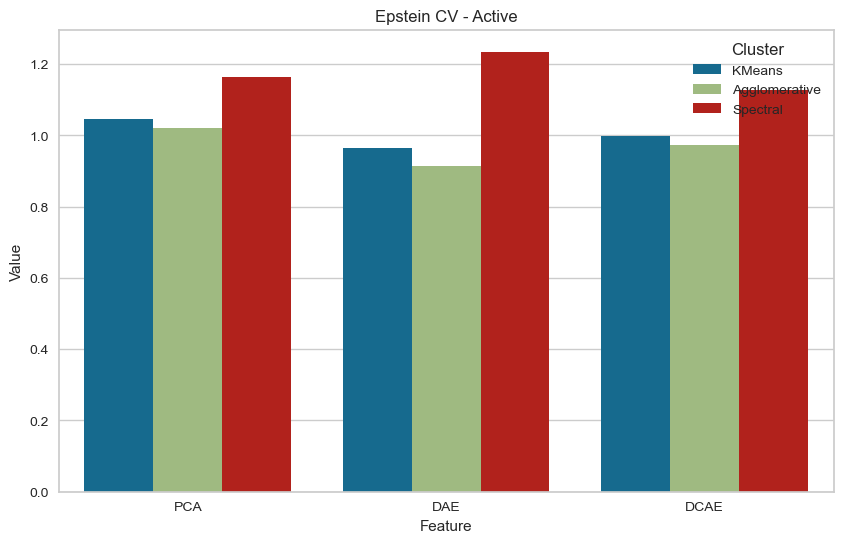

In [48]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ecv_results_active_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Epstein CV - Active")
plt.legend(title="Cluster")
#plt.ylim(10000, 20000)
plt.savefig("epstein_active_overall_norm.png", format="png")
plt.show()

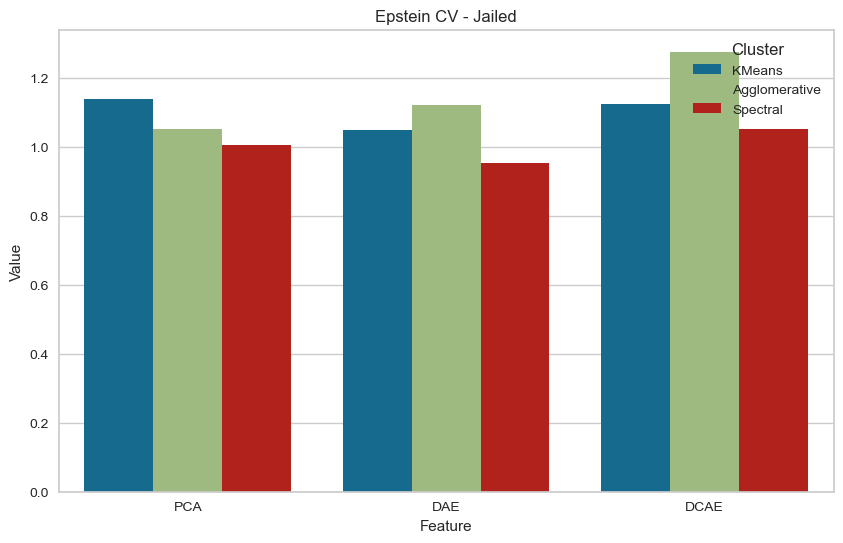

In [49]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ecv_results_jailed_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Epstein CV - Jailed")
plt.legend(title="Cluster")
#plt.ylim(10000, 25000)
plt.savefig("epstein_jailed_overall_norm.png", format="png")
plt.show()

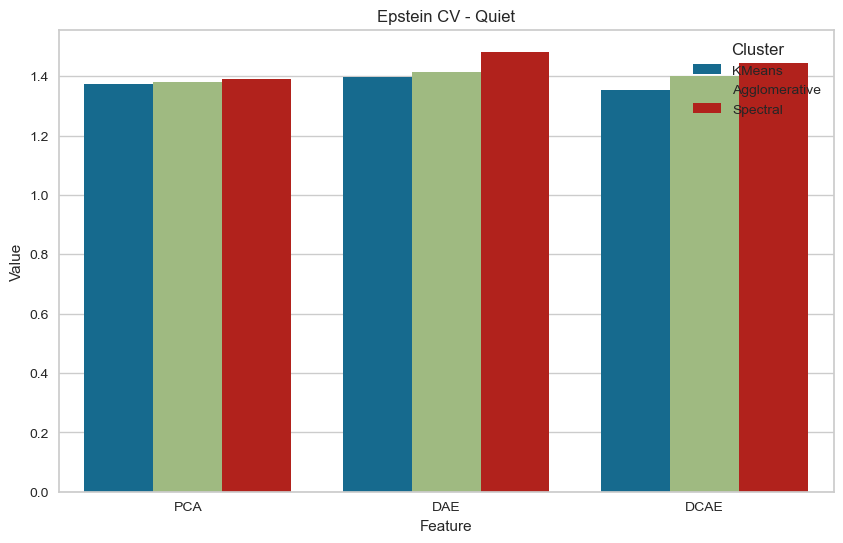

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ecv_results_quiet_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Epstein CV - Quiet")
plt.legend(title="Cluster")
#plt.ylim(15000, 45000)
plt.savefig("epstein_quiet_overall_norm.png", format="png")
plt.show()

In [51]:
def import_ff_data(filename):
    expected_columns=155
    data = []
    with open(filename, 'r') as file:
        for line in file:
            row = line.strip().split(',')
            if len(row) < expected_columns:
                row += [np.nan] * (expected_columns - len(row))
            data.append(row)
    df = pd.DataFrame(data)
    def fill_last_valid(row):
        for i in range(1, len(row)):
            if pd.isna(row[i]):
                row[i] = row[i - 1]  
        return row
    df_filled = df.apply(fill_last_valid, axis=1)
    return df_filled

In [52]:
label_results = pd.read_csv('forestfire_results.csv', index_col=0)
ff_onfire = import_ff_data("SimData/forest_fire_outputs_onfire.csv")
ff_onfire_ts = to_time_series_dataset(ff_onfire)

In [53]:
distance_ff_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ff_onfire_ts, 4, "Euclidean")
distance_ff_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ff_onfire_ts, 4, "Euclidean")
distance_ff_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ff_onfire_ts, 4, "Euclidean")

distance_ff_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ff_onfire_ts, 4, "Euclidean")
distance_ff_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ff_onfire_ts, 4, "Euclidean")
distance_ff_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ff_onfire_ts, 4, "Euclidean")

distance_ff_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ff_onfire_ts, 4, "Euclidean")
distance_ff_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ff_onfire_ts, 4, "Euclidean")
distance_ff_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ff_onfire_ts, 4, "Euclidean")

In [54]:
ff_results_onfire_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ff_pca_kmeans, distance_ff_pca_agglom, distance_ff_pca_spectral, 
              distance_ff_dae_kmeans, distance_ff_dae_agglom, distance_ff_dae_spectral,
              distance_ff_dcae_kmeans, distance_ff_dcae_agglom, distance_ff_dcae_spectral]
})

In [55]:
ff_fine = import_ff_data("SimData/forest_fire_outputs_fine.csv")
ff_fine_ts = to_time_series_dataset(ff_fine)

In [56]:
distance_ff_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ff_fine_ts, 4, "Euclidean")
distance_ff_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ff_fine_ts, 4, "Euclidean")
distance_ff_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ff_fine_ts, 4, "Euclidean")

distance_ff_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ff_fine_ts, 4, "Euclidean")
distance_ff_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ff_fine_ts, 4, "Euclidean")
distance_ff_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ff_fine_ts, 4, "Euclidean")

distance_ff_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ff_fine_ts, 4, "Euclidean")
distance_ff_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ff_fine_ts, 4, "Euclidean")
distance_ff_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ff_fine_ts, 4, "Euclidean")

In [57]:
ff_results_fine_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ff_pca_kmeans, distance_ff_pca_agglom, distance_ff_pca_spectral, 
              distance_ff_dae_kmeans, distance_ff_dae_agglom, distance_ff_dae_spectral,
              distance_ff_dcae_kmeans, distance_ff_dcae_agglom, distance_ff_dcae_spectral]
})

In [58]:
ff_burned = import_ff_data("SimData/forest_fire_outputs_burned.csv")
ff_burned_ts = to_time_series_dataset(ff_burned)

In [59]:
distance_ff_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ff_burned_ts, 4, "Euclidean")
distance_ff_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ff_burned_ts, 4, "Euclidean")
distance_ff_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ff_burned_ts, 4, "Euclidean")

distance_ff_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ff_burned_ts, 4, "Euclidean")
distance_ff_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ff_burned_ts, 4, "Euclidean")
distance_ff_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ff_burned_ts, 4, "Euclidean")

distance_ff_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ff_burned_ts, 4, "Euclidean")
distance_ff_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ff_burned_ts, 4, "Euclidean")
distance_ff_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ff_burned_ts, 4, "Euclidean")

In [60]:
ff_results_burned_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ff_pca_kmeans, distance_ff_pca_agglom, distance_ff_pca_spectral, 
              distance_ff_dae_kmeans, distance_ff_dae_agglom, distance_ff_dae_spectral,
              distance_ff_dcae_kmeans, distance_ff_dcae_agglom, distance_ff_dcae_spectral]
})

In [61]:
ff_results_onfire_df['Value'] = ff_results_onfire_df['Value'].apply(lambda x: x/6813.597927437933)
ff_results_fine_df['Value'] = ff_results_fine_df['Value'].apply(lambda x: x/235781.35510975076)
ff_results_burned_df['Value'] = ff_results_burned_df['Value'].apply(lambda x: x/241855.09660309585)

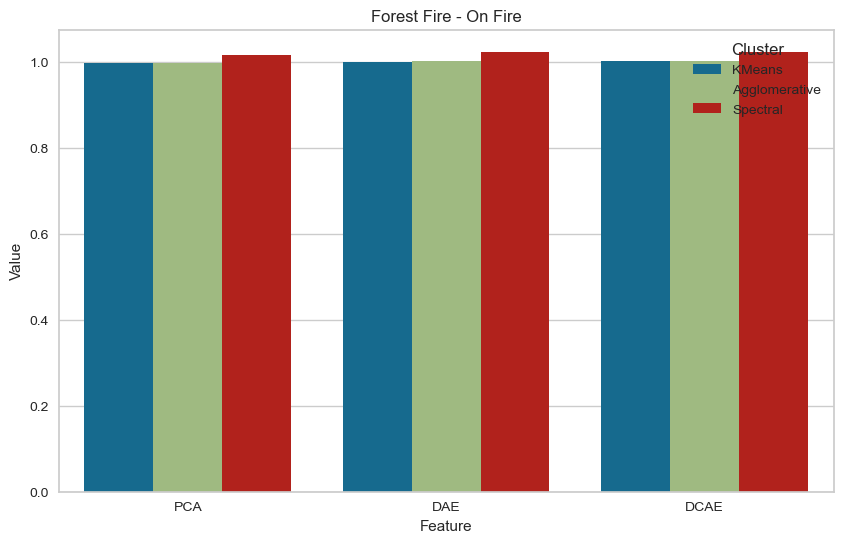

In [65]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ff_results_onfire_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Forest Fire - On Fire")
plt.legend(title="Cluster")
#plt.ylim(5000, 8000)
plt.savefig("ff_onfire_overall_norm.png", format="png")
plt.show()

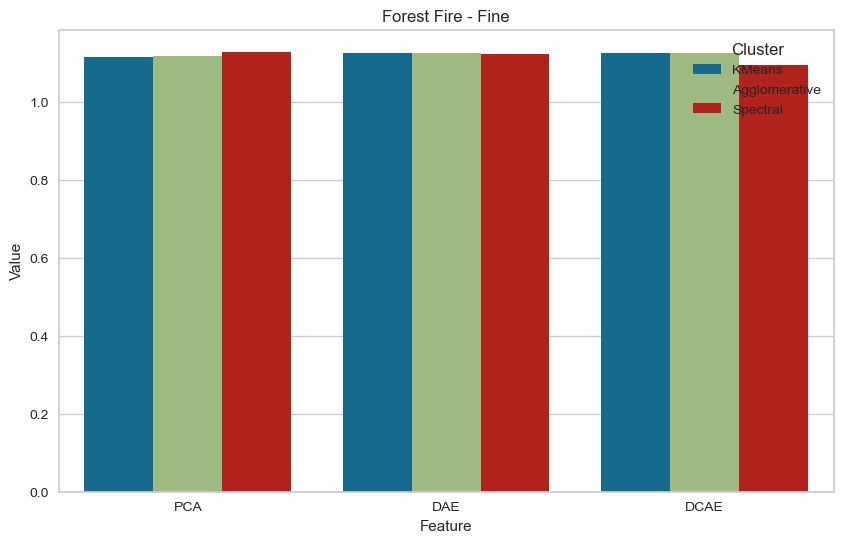

In [66]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ff_results_fine_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Forest Fire - Fine")
plt.legend(title="Cluster")
#plt.ylim(200000, 290000)
plt.savefig("ff_fine_overall_norm.png", format="png")
plt.show()

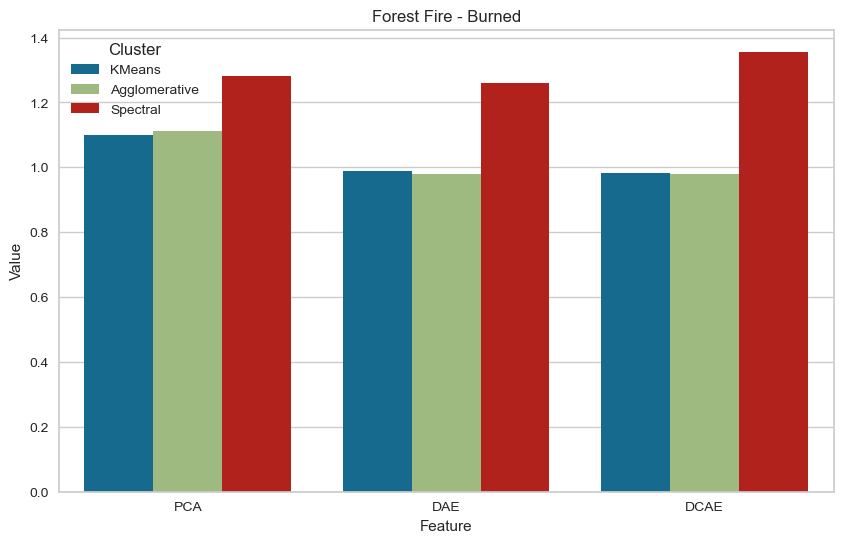

In [67]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ff_results_burned_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Forest Fire - Burned")
plt.legend(title="Cluster")
#plt.ylim(200000, 350000)
plt.savefig("ff_burned_overall_norm.png", format="png")
plt.show()